# Assignment 2 — Streaming Outlier Detection with Physiological Sensor Data

**CSC 84030 — Big Data Analytics**

**Name:** `<your name>`  
**Date:** `<submission date>`

---

This notebook walks you through detecting physiological outliers (potential stress events) in WESAD wearable sensor data using two approaches:
1. **Reservoir Sampling** — a streaming algorithm that maintains a running baseline estimate
2. **Isolation Forest** — a batch-trained anomaly detection model

Read the instructions in each section carefully. Cells marked `# PROVIDED` are complete. Cells marked `# TODO` require your implementation.

### Note: the results are NOT intuitve - feel free to rerun on other subjects, but for S2 the results will suprise you.

In [1]:
# PROVIDED — imports and display settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import IsolationForest
import pickle
import json
import random
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['font.size'] = 11

# Condition label map
CONDITION_COLORS = {0: 'white', 1: '#c8e6c9', 2: '#ffcdd2', 3: '#bbdefb'}
CONDITION_NAMES  = {0: 'transition', 1: 'baseline', 2: 'stress', 3: 'amusement'}
print('Imports OK')

Imports OK


---
## Section 1 — Data Exploration

**Points: 15**

Load the preprocessed dataset and explore the physiological signals across the three experimental conditions.

In [2]:
# PROVIDED — load the preprocessed CSV
df = pd.read_csv('wesad_S2_1hz.csv', parse_dates=['datetime'])
print(f'Loaded {len(df):,} rows spanning {df.seconds_elapsed.max()/60:.1f} minutes')
print(f'Conditions present: {df.condition_name.value_counts().to_dict()}')
df.head()

Loaded 7,864 rows spanning 131.1 minutes
Conditions present: {'unknown/transition': 5743, 'baseline': 1144, 'stress': 615, 'amusement': 362}


,timestamp,datetime,eda,temp,hr,acc_mag,bvp_mean,condition,condition_name,seconds_elapsed
0,1.495437e+09,2017-05-22 07:15:35+00:00,0.500360,35.13,101.00,0.979466,-6.367344,0,unknown/transition,0
1,1.495437e+09,2017-05-22 07:15:36+00:00,0.497156,35.15,106.50,0.979090,6.501719,0,unknown/transition,1
2,1.495437e+09,2017-05-22 07:15:37+00:00,0.493633,35.15,95.33,0.978290,2.537344,0,unknown/transition,2
3,1.495437e+09,2017-05-22 07:15:38+00:00,0.490109,35.15,90.25,0.977515,11.290156,0,unknown/transition,3
4,1.495437e+09,2017-05-22 07:15:39+00:00,0.486585,35.16,88.20,0.978183,-2.501562,0,unknown/transition,4


In [3]:
# PROVIDED — helper to shade plot background by condition
def shade_conditions(ax, df):
    """Color background of a matplotlib axis by condition label."""
    prev_cond = df['condition'].iloc[0]
    start_t   = df['seconds_elapsed'].iloc[0]
    for _, row in df.iterrows():
        if row['condition'] != prev_cond:
            ax.axvspan(start_t, row['seconds_elapsed'],
                       facecolor=CONDITION_COLORS[prev_cond], alpha=0.4)
            prev_cond = row['condition']
            start_t   = row['seconds_elapsed']
    ax.axvspan(start_t, df['seconds_elapsed'].iloc[-1],
               facecolor=CONDITION_COLORS[prev_cond], alpha=0.4)

# PROVIDED — legend patches
legend_patches = [mpatches.Patch(color=c, label=CONDITION_NAMES[k], alpha=0.6)
                  for k, c in CONDITION_COLORS.items() if k > 0]
print('Helper defined')

Helper defined


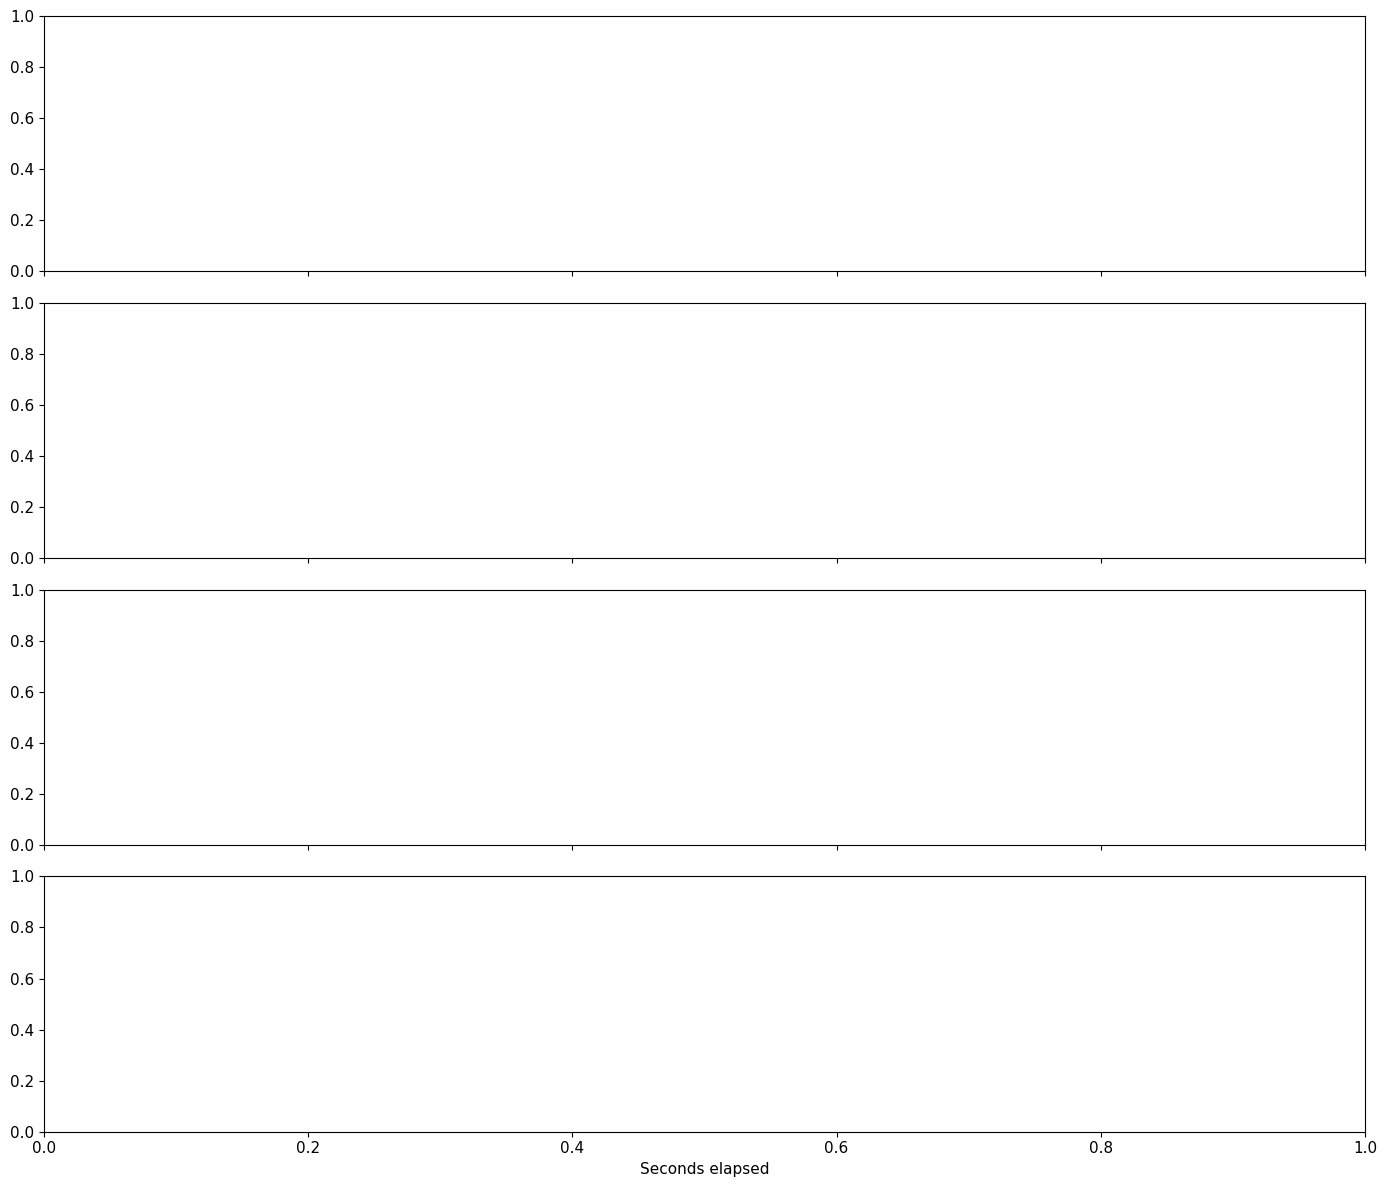

In [4]:
# TODO (1.1) — Plot all four signals as time series with condition shading
# 
# For each of the four signals: eda, hr, temp, acc_mag
#   - Create a subplot (4 rows x 1 col, shared x-axis)
#   - Plot the signal vs seconds_elapsed
#   - Call shade_conditions(ax, df) to color the background
#   - Add a ylabel with the signal name and unit
#   - Add a legend for conditions on the last subplot
#
# Your code here:
signals = [('eda', 'EDA (μS)'), ('hr', 'HR (bpm)'), ('temp', 'Temp (°C)'), ('acc_mag', 'Acc. Mag. (g)')]

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(14, 12))
for ax, (col, label) in zip(axes, signals):
    # YOUR CODE HERE
    pass

axes[-1].set_xlabel('Seconds elapsed')
plt.tight_layout()
plt.show()

In [5]:
# TODO (1.2) — Per-condition statistics table
#
# Compute the mean and standard deviation of each signal (eda, hr, temp, acc_mag)
# grouped by condition_name. Display a nicely formatted table.
# Hint: use df.groupby('condition_name')[signals].agg(['mean', 'std']).round(3)
#
# Your code here:


**TODO (1.3) — Written answer:** Which signal shows the most visible difference between baseline and stress? Justify your answer using specific statistics from the table above.

*Your answer here (2–3 sentences):*

---
## Section 2 — Reservoir Sampling

**Points: 25**

Reservoir Sampling (Algorithm R) is a one-pass streaming algorithm that maintains a fixed-size, uniformly random sample from a data stream of unknown length.

**Algorithm R:**
```
Given a reservoir of size k:
  For each incoming element i (0-indexed):
    If i < k:              fill the reservoir directly
    Else:
      j = random integer in [0, i]  (inclusive)
      If j < k:            replace reservoir[j] with the new element
```

This guarantees each past element has probability `k / (i+1)` of being in the reservoir at step `i`.

In [6]:
# TODO (2a) — Implement ReservoirSampler

class ReservoirSampler:
    """
    Fixed-size reservoir sampler using Algorithm R.
    
    Parameters
    ----------
    capacity : int
        Maximum number of elements to keep in the reservoir.
    """

    def __init__(self, capacity: int):
        self.capacity = capacity
        self.reservoir = []   # list of floats — max length = capacity
        self._n_seen = 0      # total number of elements seen so far
        # YOUR CODE HERE (add any other attributes you need)

    def update(self, value: float) -> None:
        """
        Process one new value from the stream.
        Implements Algorithm R: keeps a uniform random sample of size `capacity`.
        """
        # YOUR CODE HERE
        pass

    def sample_mean(self) -> float:
        """Return the mean of the current reservoir contents."""
        # YOUR CODE HERE
        pass

    def sample_std(self) -> float:
        """
        Return the standard deviation of the current reservoir contents.
        Return 1.0 if the reservoir has fewer than 2 elements (avoid division by zero).
        """
        # YOUR CODE HERE
        pass

    def __len__(self):
        return len(self.reservoir)


# PROVIDED — quick sanity checks (do not modify)
def test_reservoir():
    rs = ReservoirSampler(capacity=10)
    for v in range(100):
        rs.update(float(v))
    assert len(rs.reservoir) == 10, "Reservoir must stay at exactly capacity size"
    assert all(0 <= v <= 99 for v in rs.reservoir), "All values must be from the stream"
    assert rs.sample_mean() is not None
    assert rs.sample_std() is not None

    # Verify uniformity (approximate): all 100 values should have ~equal chance of inclusion
    # Run many trials and check no value is systematically excluded
    counts = {i: 0 for i in range(100)}
    for _ in range(5000):
        rs2 = ReservoirSampler(capacity=10)
        for v in range(100):
            rs2.update(float(v))
        for v in rs2.reservoir:
            counts[int(v)] += 1
    expected = 5000 * 10 / 100
    for v, cnt in counts.items():
        assert 0.5 * expected <= cnt <= 2 * expected, (
            f"Value {v} appeared {cnt} times (expected ~{expected:.0f}). "
            "Check that your random replacement is truly uniform."
        )
    print('All reservoir tests passed!')

test_reservoir()

AssertionError: Reservoir must stay at exactly capacity size

In [ ]:
# TODO (2b) — Streaming z-score outlier detection using the reservoir
#
# Process the EDA signal row-by-row (in time order) and for each row:
#   1. Update the reservoir with the current EDA value
#   2. Compute z = (eda - reservoir.sample_mean()) / reservoir.sample_std()
#   3. Flag as outlier if abs(z) > 2.5
#
# Store results in new columns on df:
#   df['reservoir_z']        — z-score at each timestep
#   df['reservoir_outlier']  — True/False
#   df['reservoir_mean']     — running reservoir mean (for plotting)
#   df['reservoir_std']      — running reservoir std  (for plotting)

CAPACITY = 500
THRESHOLD = 2.5

sampler = ReservoirSampler(capacity=CAPACITY)

z_scores     = []
outlier_flags = []
running_means = []
running_stds  = []

for eda_val in df['eda']:
    # YOUR CODE HERE
    pass

df['reservoir_z']       = z_scores
df['reservoir_outlier'] = outlier_flags
df['reservoir_mean']    = running_means
df['reservoir_std']     = running_stds

print(f'Total outliers detected: {df.reservoir_outlier.sum()}')
print(df.groupby('condition_name')['reservoir_outlier'].sum())

In [ ]:
# TODO (2b continued) — Plot the EDA signal with outliers highlighted and ±2.5σ band
#
# Create a single plot with:
#   - EDA signal as a line (blue)
#   - Condition shading (call shade_conditions)
#   - Outlier points marked as red dots
#   - Reservoir mean as a dashed black line
#   - Shaded band: reservoir_mean ± 2.5 * reservoir_std (light gray, alpha=0.3)
#   - Appropriate title, labels, and legend
#
# YOUR CODE HERE:
fig, ax = plt.subplots(figsize=(14, 5))

# YOUR CODE HERE

ax.set_xlabel('Seconds elapsed')
ax.set_ylabel('EDA (μS)')
ax.set_title('EDA Signal — Reservoir Sampling Outlier Detection')
plt.tight_layout()
plt.show()

In [ ]:
# TODO (2b continued) — Effect of reservoir capacity
#
# Re-run your streaming z-score detection with capacity=100 and capacity=1000.
# For each, print the number of outliers per condition.
# You may reuse your loop from above — just change CAPACITY.
#
# YOUR CODE HERE:
for cap in [100, 1000]:
    # YOUR CODE HERE
    pass

**TODO (2b) — Written answer:**

1. How many outliers were detected in the stress condition vs. baseline (with `capacity=500`)?
2. What is the effect of reservoir capacity on detection quality? What did you observe with `capacity=100` vs `capacity=1000`?

*Your answer here (3–5 sentences):*

### OPTIONAL: Check out heart rate (hr) as well!

---
## Section 3 — Isolation Forest

**Points: 25**

Isolation Forest works by randomly partitioning the feature space. Anomalies, being rare and different, require fewer splits to isolate — so they get low anomaly scores. We train on baseline data only, then apply to all windows.

In [ ]:
# TODO (3a) — Feature extraction: 30-second non-overlapping windows
#
# 1. Add a column 'window_id' = seconds_elapsed // 30  (integer division)
# 2. Group by window_id and compute:
#       mean_eda, std_eda, mean_hr, mean_temp, mean_acc_mag
# 3. Also capture the majority condition label per window (for evaluation later)
# 4. Store result in `windows_df` — one row per window
#
# Hint: use groupby + agg with a dict, then rename columns

df['window_id'] = (df['seconds_elapsed'] // 30).astype(int)

# YOUR CODE HERE:
windows_df = None  # replace this

print(f'Number of 30-second windows: {len(windows_df)}')
windows_df.head()

In [ ]:
# TODO (3b) — Train Isolation Forest on baseline windows only
#
# FEATURE_COLS are the five columns you computed above.
# 1. Filter windows_df to keep only baseline windows (condition == 1)
# 2. Fit IsolationForest on those windows
# 3. Save the trained model to 'isolation_forest.pkl' using pickle

FEATURE_COLS = ['mean_eda', 'std_eda', 'mean_hr', 'mean_temp', 'mean_acc_mag']

# NOTE: WE ARE NOT OPTIMIZING THE MODEL OR TUNING HYPERPARAMETERS — JUST TRAINING A BASIC MODEL AS THIS IS NOT AN ML COURSE
# YOUR CODE HERE:
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

# Filter to baseline, fit, then save:

print(f'Trained on {0} baseline windows')  # update the 0

In [ ]:
# TODO (3c) — Apply the model to all windows
#
# 1. Call model.predict() → store result in windows_df['iso_outlier']
#    (the model returns 1 for inlier, -1 for outlier; convert to True/False)
# 2. Call model.decision_function() → store in windows_df['iso_score']
#    (lower = more anomalous)

# YOUR CODE HERE:

# Show outlier fraction per condition
print(windows_df.groupby('condition_name')['iso_outlier'].mean().round(3))

In [ ]:
# TODO (3c continued) — Plot iso_score over time with outliers marked
#
# x-axis: window_id (or window_id * 30 seconds for a time axis)
# y-axis: iso_score
# - Plot score as a line
# - Mark outlier windows (iso_outlier == True) with red dots
# - Add a horizontal dashed line at y=0 (the rough inlier/outlier threshold)
# - Shade background by condition (you'll need to map window_id back to condition)

# PROVIDED — map window majority-condition back to the windows_df for shading
# (windows_df should already have a 'condition' column from your groupby in 3a)

fig, ax = plt.subplots(figsize=(14, 4))

# YOUR CODE HERE

ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Isolation Forest score')
ax.set_title('Isolation Forest Anomaly Score over Time')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, label='threshold')
plt.tight_layout()
plt.show()

**TODO (3c) — Written answer:**

1. What fraction of stress windows were detected as outliers? What fraction of baseline windows?
2. Does it matter that you trained only on baseline data? What would happen if you trained on all conditions?

*Your answer here (3–5 sentences):*

---
## Section 4 — Spark Structured Streaming

**Points: 15**

Open `spark_streaming_template.py`. The window aggregation (Section 3) is already provided — it mirrors what you did in Part 3a above. Your only task is **Section 4**: fill in the body of `score_window_udf` to load your saved `isolation_forest.pkl` and return a score from `model.decision_function()`. The docstring in the template explains exactly what to write.

Run the cell below first to save your model, then run the script from the terminal:

```bash
python spark_streaming_template.py
```

In [ ]:
# PROVIDED — Save your trained Isolation Forest model so the Spark script can load it.
# Run this after completing Part 3b.

with open('isolation_forest.pkl', 'wb') as f:
    pickle.dump(model, f)
print('Saved isolation_forest.pkl')

**TODO (4) — Paste the first batch of Spark console output below:**

```
< paste output here >
```

---
## Section 5 — Comparison & Analysis

**Points: 20**

**TODO (5) — Fill in the comparison table:**

| Dimension | Reservoir Sampling | Isolation Forest |
|---|---|---|
| Requires training data? | | |
| Updates with new data? | | |
| Latency (per sample) | | |
| Precision on stress windows | | |
| False positive rate on baseline | | |

**TODO (5) — Answer the following questions (2–4 sentences each):**

**Q1.** Which method had higher precision for detecting stress windows? Support your answer with specific numbers from Parts 2 and 3.

*Your answer:*

---

**Q2.** What is the key algorithmic reason Reservoir Sampling works without storing all past data?

*Your answer:*

---

**Q3.** What happens to your Isolation Forest if the physiological baseline shifts over a long session? How would you fix this?

*Your answer:*

---

**Q4.** Algorithm R probability check — show your calculation.

The full S2 recording has 7,864 rows, of which 611 are labeled `stress`. Your reservoir capacity is 500. After processing all rows:
- What is the probability that any single stress row ends up in the reservoir?
- What is the expected number of stress-condition samples in the reservoir?

*Your answer (show the formula and arithmetic):*